<a href="https://www.kaggle.com/code/rohit4468/complaint-priority-system?scriptVersionId=307148279" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tobiasbueck/multilingual-customer-support-tickets/dataset-tickets-multi-lang-4-20k.csv
/kaggle/input/datasets/tobiasbueck/multilingual-customer-support-tickets/dataset-tickets-german_normalized_50_5_2.csv
/kaggle/input/datasets/tobiasbueck/multilingual-customer-support-tickets/dataset-tickets-multi-lang3-4k.csv
/kaggle/input/datasets/tobiasbueck/multilingual-customer-support-tickets/dataset-tickets-german_normalized.csv
/kaggle/input/datasets/tobiasbueck/multilingual-customer-support-tickets/aa_dataset-tickets-multi-lang-5-2-50-version.csv
/kaggle/input/datasets/coderanand/university-query-priority-classification/university_query_train.csv
/kaggle/input/datasets/coderanand/university-query-priority-classification/university_query_test.csv
/kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv
/kaggle/input/datasets/ajverse/customer-support-tickets-crm-dataset/customer_support_tickets.csv
/kaggle/input/datasets/ajverse/custome

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DataFrame

In [3]:
# file 1: CCSAP
FILE1='/kaggle/input/datasets/xjoury/customer-complaints-sentiment-and-priority-dataset/Customer Complaints Sentiment and Priority Dataset.csv'
df_1=pd.read_csv(FILE1)
print(df_1.shape)
df_1.head(5)


(1750, 4)


,Consumer_complaint,Product,Sentiment,Priority
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service,0,1
1,"I am the sole, legal representative of my dece...",Checking or savings account or service,0,1
2,This bank has consistantly manipulated my dire...,Checking or savings account or service,0,0
3,I enrolled in a Citibank checking account in X...,Checking or savings account or service,0,1
4,TIAA-XXXX has not responded to multiple reque...,Checking or savings account or service,0,1


In [4]:
# file 2: CCTD
FILE2='/kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv'
df_2=pd.read_csv(FILE2)
print(df_2.shape)
df_2.head(5)


(8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
# file 3: CSTD 200K
FILE3='/kaggle/input/datasets/mirzayasirabdullah07/customer-support-tickets-dataset-200k-records/customer_support_tickets_200k.csv'
df_3=pd.read_csv(FILE3)
print(df_3.shape)
df_3.head(5)


(200000, 30)


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [6]:
# file 4: University 
df_train=pd.read_csv('/kaggle/input/datasets/coderanand/university-query-priority-classification/university_query_train.csv')
df_test=pd.read_csv('/kaggle/input/datasets/coderanand/university-query-priority-classification/university_query_test.csv')

df_4= pd.concat([df_train,df_test], axis=0, ignore_index=True)
print(df_4.shape)
df_4.head(4)


(6000, 5)


,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,1783,How to join student clubs?,Examination Cell,31,Low
1,3918,My admit card has incorrect details.,Examination Cell,48,High
2,222,How to reset my university portal password?,Finance Office,5,Medium
3,2136,My exam form is not submitted and tomorrow is ...,Academic Office,18,High


In [7]:
# file 5: CST CRM
FILE5='/kaggle/input/datasets/ajverse/customer-support-tickets-crm-dataset/enhanced_customer_support_data.csv'
df_5=pd.read_csv(FILE5)
print(df_5.shape)
df_5.head(5)


(20000, 12)


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [8]:
# file 6: tick system helpdesk
FILE6='/kaggle/input/datasets/tobiasbueck/multilingual-customer-support-tickets/aa_dataset-tickets-multi-lang-5-2-50-version.csv'
df_6=pd.read_csv(FILE6, encoding='utf-8')
print(df_6.shape)
df_6.head(5)


(28587, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


# file 1 

In [9]:
df_1

,Consumer_complaint,Product,Sentiment,Priority
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service,0,1
1,"I am the sole, legal representative of my dece...",Checking or savings account or service,0,1
2,This bank has consistantly manipulated my dire...,Checking or savings account or service,0,0
3,I enrolled in a Citibank checking account in X...,Checking or savings account or service,0,1
4,TIAA-XXXX has not responded to multiple reque...,Checking or savings account or service,0,1
...,...,...,...,...
1745,This is my 2nd complaint against ocwen loan se...,Mortgage,0,1
1746,I was de-escrowed in XXXX 2014. I chose to pay...,Mortgage,1,1
1747,We were notified we were in Breach of contract...,Mortgage,0,1
1748,I changed homeowner insurance companies recent...,Mortgage,0,0


In [10]:
df_1.columns

Index(['Consumer_complaint', 'Product', 'Sentiment', 'Priority'], dtype='object')

In [11]:
df_1.shape

(1750, 4)

In [12]:
df_1['Product'].unique()

array(['Checking or savings account or service',
       'Credit card or prepaid card',
       'Credit reporting, repair, or other', 'Debt collection', 'Loans',
       'Money transfer, virtual currency, or money service', 'Mortgage'],
      dtype=object)

In [13]:
# Df 1 is all about finance with high and low priority |

<Axes: xlabel='Priority', ylabel='count'>

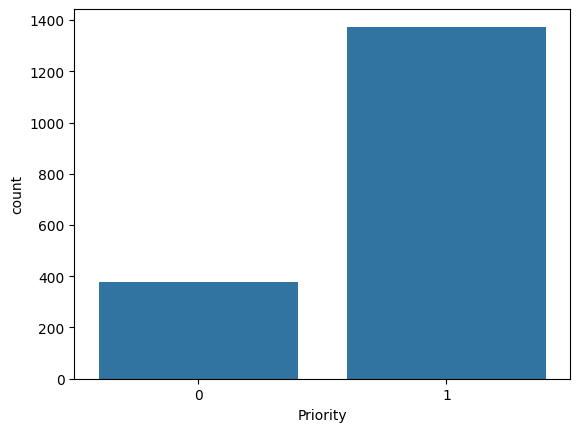

In [14]:
sns.countplot(data=df_1, x='Priority')

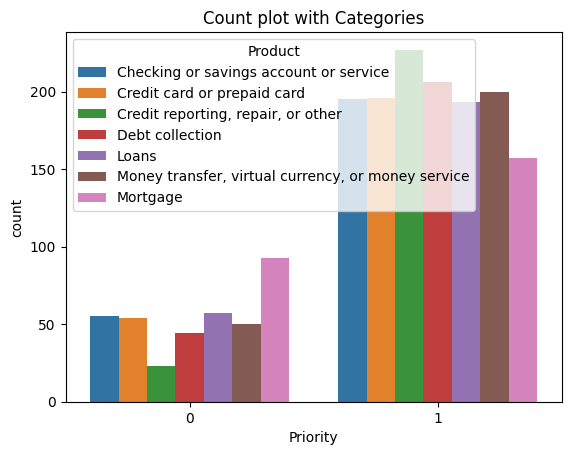

In [15]:
sns.countplot(data=df_1, x='Priority', hue='Product')
plt.title("Count plot with Categories")
plt.show()

## Feature extraction

In [16]:
df_1['category'] = 'Finance'

In [17]:
# mapping
df_1['Priority']=df_1['Priority'].map({0:'low', 1: 'high'})

In [18]:
df_1=df_1.rename(columns={'Consumer_complaint':'text', 'Priority':'priority'})
df_1.head(5)

,text,Product,Sentiment,priority,category
0,I had overdraft protection with Regions Bank i...,Checking or savings account or service,0,high,Finance
1,"I am the sole, legal representative of my dece...",Checking or savings account or service,0,high,Finance
2,This bank has consistantly manipulated my dire...,Checking or savings account or service,0,low,Finance
3,I enrolled in a Citibank checking account in X...,Checking or savings account or service,0,high,Finance
4,TIAA-XXXX has not responded to multiple reque...,Checking or savings account or service,0,high,Finance


In [19]:
df_1m=df_1[['text', 'priority','category']]
df_1m.head(5)

,text,priority,category
0,I had overdraft protection with Regions Bank i...,high,Finance
1,"I am the sole, legal representative of my dece...",high,Finance
2,This bank has consistantly manipulated my dire...,low,Finance
3,I enrolled in a Citibank checking account in X...,high,Finance
4,TIAA-XXXX has not responded to multiple reque...,high,Finance


# file 2

In [20]:
# tech product support 

In [21]:
df_2

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0


In [22]:
df_2.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [23]:
df_2['Ticket Type'].unique()

array(['Technical issue', 'Billing inquiry', 'Cancellation request',
       'Product inquiry', 'Refund request'], dtype=object)

In [24]:
df_2['Ticket Subject'].unique()

array(['Product setup', 'Peripheral compatibility', 'Network problem',
       'Account access', 'Data loss', 'Payment issue', 'Refund request',
       'Battery life', 'Installation support', 'Software bug',
       'Hardware issue', 'Product recommendation', 'Delivery problem',
       'Display issue', 'Cancellation request', 'Product compatibility'],
      dtype=object)

In [25]:
df_2['Ticket Status'].unique()

array(['Pending Customer Response', 'Closed', 'Open'], dtype=object)

In [26]:
df_2['Ticket Priority'].unique()

array(['Critical', 'Low', 'High', 'Medium'], dtype=object)

Here we have 4 categories `'Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request'`and 4 priority columns `'Critical', 'Low', 'High', 'Medium'` 

<Axes: xlabel='Ticket Priority', ylabel='count'>

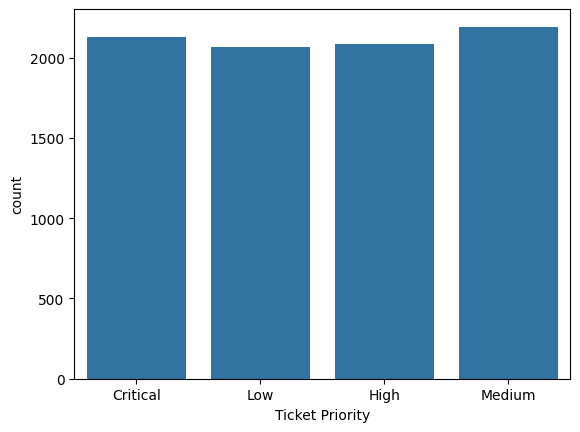

In [27]:
sns.countplot(data=df_2, x='Ticket Priority')

class balanced

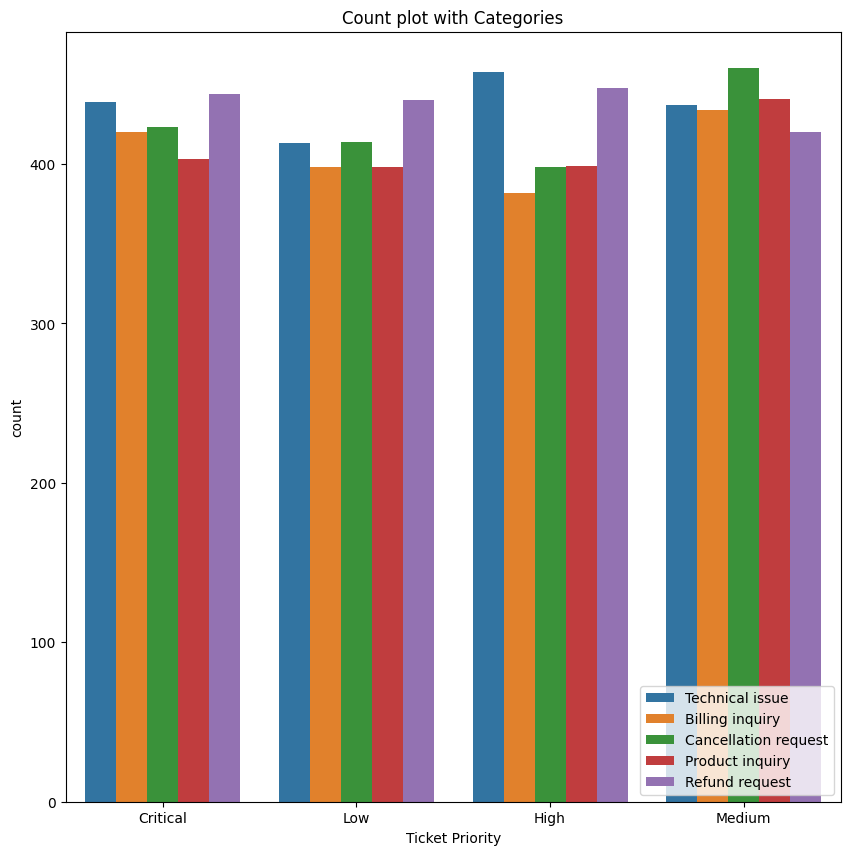

In [28]:
plt.figure(figsize=(10, 10)) 
sns.countplot(data=df_2, x='Ticket Priority', hue='Ticket Type')
plt.legend(loc='lower right')
plt.title("Count plot with Categories")
plt.show()

## Feature extraction

In [29]:
#df_2['Ticket Type']=df_2['Ticket Type'].drop()

In [30]:
#rename the columns value
df_2['Ticket Type']=df_2['Ticket Type'].replace({'Technical issue':'IT', 'Billing inquiry': 'Finance', 'Cancellation request':'Customer Service',
       'Product inquiry':'Product', 'Refund request':'Finance'})

In [31]:
df_2.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,IT,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,IT,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,IT,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Finance,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Finance,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [32]:
df_2m=df_2[['Ticket Description','Ticket Type','Ticket Priority']]

In [33]:
df_2m.rename(columns={
    'Ticket Description': 'text',
    'Ticket Type': 'category',
    'Ticket Priority': 'priority'
}, inplace=True)

/tmp/ipykernel_17/4084567074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2m.rename(columns={


In [34]:
df_2m.head(5)

,text,category,priority
0,I'm having an issue with the {product_purchase...,IT,Critical
1,I'm having an issue with the {product_purchase...,IT,Critical
2,I'm facing a problem with my {product_purchase...,IT,Low
3,I'm having an issue with the {product_purchase...,Finance,Low
4,I'm having an issue with the {product_purchase...,Finance,Low


# file 3

In [35]:
# customer service IT 

In [36]:
df_3=df_3[df_3['language']=='English']
df_3

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
16,17,Michael Wilson,michael.wilson805@hotmail.com,API Service,Subscription Cancellation,I would like to request a refund for the recen...,Subscription status corrected and confirmation...,Urgent,In Progress,Email,...,2023-10-29,Yes,Yes,MacOS,Edge,Crypto,English,Night,7,Corporate
20,21,Richard Garcia,richard.garcia861@icloud.com,Billing System,Security Concern,I am unable to access my account after enterin...,Bug logged internally and workaround shared wi...,Low,Open,Web Form,...,2022-09-28,No,No,Android,Edge,PayPal,English,Night,1,Corporate
37,38,Charles Lopez,charles.lopez589@outlook.com,Billing System,Refund Request,I am experiencing very slow performance while ...,We have reset the account credentials and advi...,Low,Closed,Web Form,...,2023-08-28,Yes,Yes,Windows,Safari,Bank Transfer,English,Evening,3,Individual
40,41,Linda Moore,linda.moore139@icloud.com,Payment Gateway,Security Concern,Two-factor authentication codes are not being ...,Explained billing breakdown and clarified appl...,Urgent,Open,Web Form,...,2024-07-23,No,Yes,Android,NaN,PayPal,English,Night,5,Individual
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199976,199977,Richard Williams,richard.williams830@outlook.com,Mobile App,Data Sync Issue,I would like to request a refund for the recen...,Subscription status corrected and confirmation...,Medium,Open,Chat,...,2023-08-18,Yes,No,Windows,NaN,Credit Card,English,Afternoon,10,Small Business
199986,199987,Jessica Miller,jessica.miller677@hotmail.com,Analytics Dashboard,Security Concern,I am experiencing very slow performance while ...,Explained billing breakdown and clarified appl...,Urgent,Open,Social Media,...,2023-11-15,Yes,Yes,iOS,Edge,Credit Card,English,Night,3,Corporate
199988,199989,James Brown,james.brown737@icloud.com,Cloud Storage,Login Issue,I am unable to access my account after enterin...,Payment gateway timeout issue fixed and monito...,Urgent,Resolved,Social Media,...,2023-09-10,No,No,Android,Edge,Debit Card,English,Morning,10,Small Business
199992,199993,William Wilson,william.wilson238@yahoo.com,Billing System,Login Issue,I would like to request a refund for the recen...,Subscription status corrected and confirmation...,High,In Progress,Web Form,...,2024-04-28,Yes,Yes,iOS,NaN,Bank Transfer,English,Evening,8,Small Business


In [37]:
df_3.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='object')

In [38]:
df_3.shape

(33553, 30)

In [39]:
df_3['category'].unique()

array(['Performance Issue', 'Subscription Cancellation',
       'Security Concern', 'Refund Request', 'Login Issue',
       'Feature Request', 'Account Suspension', 'Payment Problem',
       'Data Sync Issue', 'Bug Report'], dtype=object)

In [40]:
df_3['priority'].unique()

array(['Urgent', 'Low', 'Medium', 'High'], dtype=object)

In [41]:
df_3['status'].unique()

array(['Closed', 'In Progress', 'Open', 'Pending Customer', 'Resolved'],
      dtype=object)

Here we have `Performance Issue', 'Subscription Cancellation','Security Concern', 'Refund Request', 'Login Issue','Feature Request', 'Account Suspension', 'Payment Problem','Data Sync Issue', 'Bug Report'` and 4 priority columns `'Urgent', 'Low', 'Medium', 'High'`

<Axes: xlabel='priority', ylabel='count'>

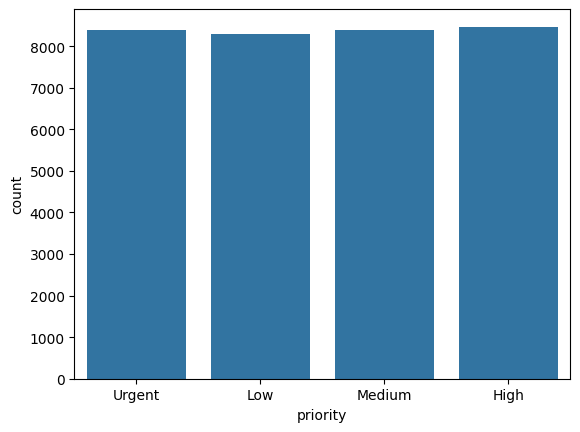

In [42]:
sns.countplot(data=df_3, x='priority')

class balanced

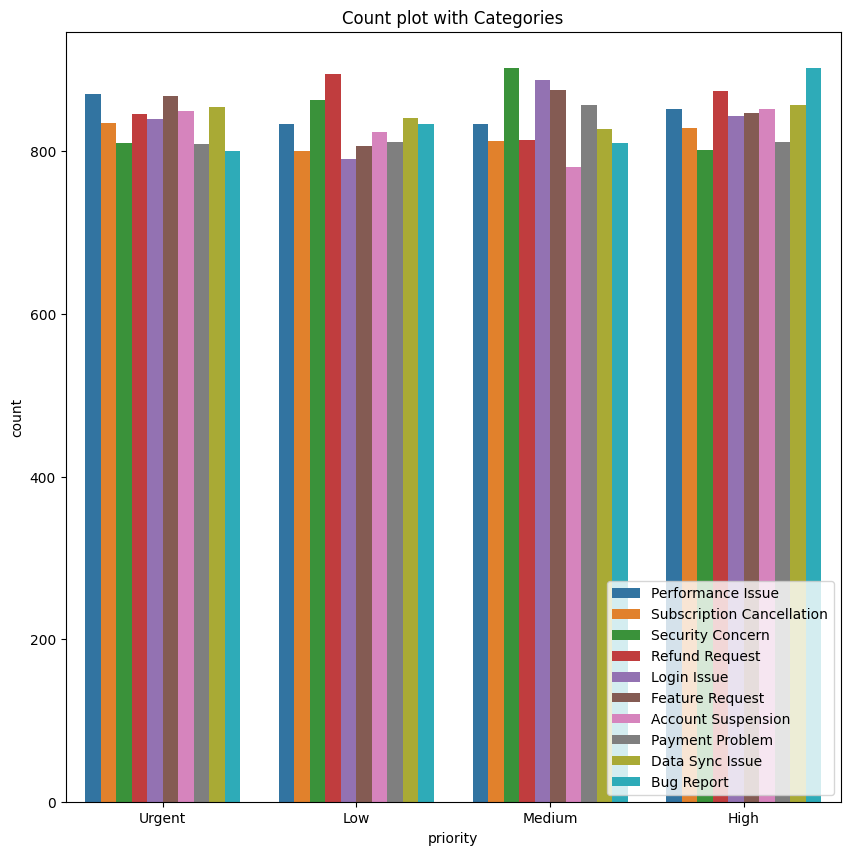

In [43]:
plt.figure(figsize=(10, 10)) 
sns.countplot(data=df_3, x='priority', hue='category')
plt.legend(loc='lower right')
plt.title("Count plot with Categories")
plt.show()

## Features Extractions 

In [44]:
df_3.shape

(33553, 30)

In [45]:
df_3['category'].value_counts()

category
Refund Request               3429
Feature Request              3397
Performance Issue            3389
Data Sync Issue              3381
Security Concern             3377
Login Issue                  3362
Bug Report                   3345
Account Suspension           3306
Payment Problem              3289
Subscription Cancellation    3278
Name: count, dtype: int64

In [46]:
#catogires rename
df_3['category']=df_3['category'].replace({'Refund Request':'Finance','Feature Request': 'Customer Service','Performance Issue':'Product','Data Sync Issue':'IT', 'Security Concern': 'Security', 'Login Issue':'IT','Bug Report':'IT', 'Account Suspension':'Security', 'Payment Problem':'Finance','Subscription Cancellation':'Product' })

In [47]:
df_3['category'].value_counts()

category
IT                  10088
Finance              6718
Security             6683
Product              6667
Customer Service     3397
Name: count, dtype: int64

In [48]:
df_3m=df_3[['issue_description','priority','category']]

In [49]:
df_3m=df_3m.rename(columns={'issue_description':'text'})
df_3m

,text,priority,category
1,I found a bug in the latest update affecting r...,Urgent,Product
16,I would like to request a refund for the recen...,Urgent,Product
20,I am unable to access my account after enterin...,Low,Security
37,I am experiencing very slow performance while ...,Low,Finance
40,Two-factor authentication codes are not being ...,Urgent,Security
...,...,...,...
199976,I would like to request a refund for the recen...,Medium,IT
199986,I am experiencing very slow performance while ...,Urgent,Security
199988,I am unable to access my account after enterin...,Urgent,IT
199992,I would like to request a refund for the recen...,High,IT


# file 4

In [50]:
# this data is of student support

In [51]:
df_4

,Query_ID,Student_Query,Department,Days_To_Deadline,Priority_Label
0,1783,How to join student clubs?,Examination Cell,31,Low
1,3918,My admit card has incorrect details.,Examination Cell,48,High
2,222,How to reset my university portal password?,Finance Office,5,Medium
3,2136,My exam form is not submitted and tomorrow is ...,Academic Office,18,High
4,5225,I cannot download my hall ticket for tomorrow'...,Administration,43,High
...,...,...,...,...,...
5995,3773,I want to change my elective subject.,IT Support,53,Medium
5996,5192,I have not received my scholarship amount.,IT Support,47,High
5997,5227,My exam form is not submitted and tomorrow is ...,Academic Office,4,High
5998,5391,My exam form is not submitted and tomorrow is ...,IT Support,7,High


In [52]:
df_4['Department'].unique()

array(['Examination Cell', 'Finance Office', 'Academic Office',
       'Administration', 'IT Support', 'Library', 'Hostel Office'],
      dtype=object)

In [53]:
df_4['Priority_Label'].unique()

array(['Low', 'High', 'Medium'], dtype=object)

This cotains  7 academics `Examination Cell', 'Finance Office', 'Academic Office', 'Administration', 'IT Support', 'Library', 'Hostel Office' and `, 3 priority columns  `Low', 'High', 'Medium'`

<Axes: xlabel='Priority_Label', ylabel='count'>

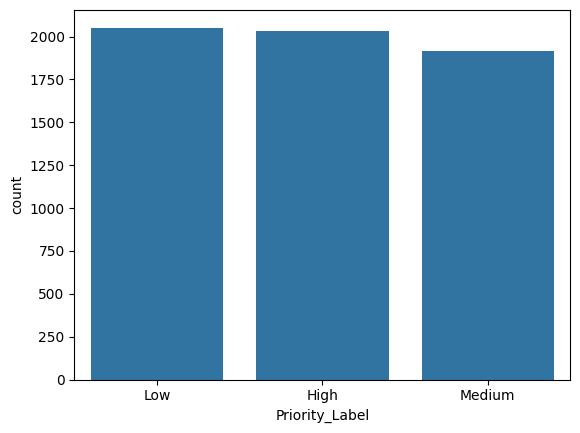

In [54]:
sns.countplot(data=df_4, x='Priority_Label')

Balanced classed

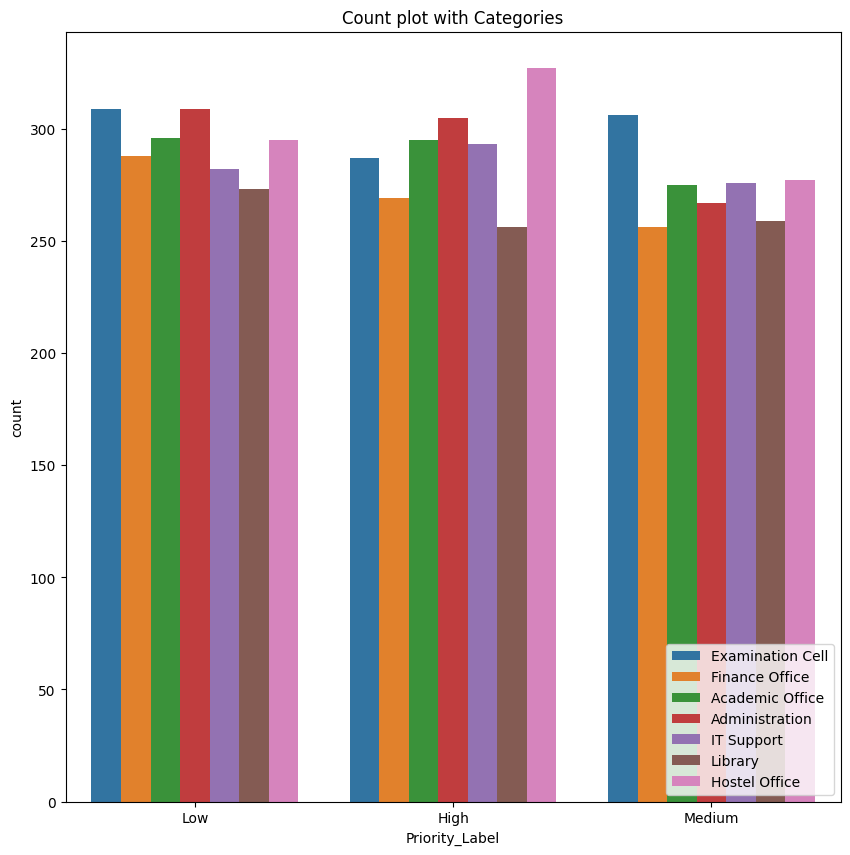

In [55]:
plt.figure(figsize=(10, 10)) 
sns.countplot(data=df_4, x='Priority_Label', hue='Department')
plt.legend(loc='lower right')
plt.title("Count plot with Categories")
plt.show()

## feature Extraction 

In [56]:
df_4['Department']='Education'

In [57]:
df_4m=df_4[['Student_Query','Department','Priority_Label']]

#rename the column names
df_4m=df_4m.rename(columns={'Student_Query':'text','Priority_Label':'priority','Department':'category'})

# file 5

` ai genrated `

In [58]:
df_5

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,TKT-119995,Jason Stewart,Susan.Valenzuela@enterprise.org,Installation issue - Think,"Hi Support, The application crashes every time...",Technical,High,Web Form,2025-02-05,6,Anya Sharma,4
19996,TKT-119996,Amy Moore,meganfranklin@example.net,Alert notification - Reality,"Hi Support, I received a suspicious email clai...",Fraud,Critical,Chat,2024-08-07,10,Elena Rodriguez,3
19997,TKT-119997,Ann Smith,Matthew.Landry@tech.io,Subscription upgrade - Spring,"Hi Support, My profile picture is not updating...",Account,Medium,Web Form,2025-10-07,2,David Kim,4
19998,TKT-119998,Dennis Moore,traceyreed@example.com,Suspicious charge - Even,"Hi Support, I have been trying to update my pa...",Billing,High,Web Form,2024-01-31,8,Anya Sharma,1


In [59]:
df_5.columns

Index(['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject',
       'Ticket_Description', 'Issue_Category', 'Priority_Level',
       'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours',
       'Assigned_Agent', 'Satisfaction_Score'],
      dtype='object')

In [60]:
df_5['Issue_Category'].unique()

array(['General Inquiry', 'Technical', 'Account', 'Billing', 'Fraud'],
      dtype=object)

In [61]:
df_5['Priority_Level'].unique()

array(['High', 'Low', 'Medium', 'Critical'], dtype=object)

This has 6 categories `'General Inquiry', 'Technical', 'Account', 'Billing', 'Fraud'` and 4 priority columns `'High', 'Low', 'Medium', 'Critical'`

<Axes: xlabel='Priority_Level', ylabel='count'>

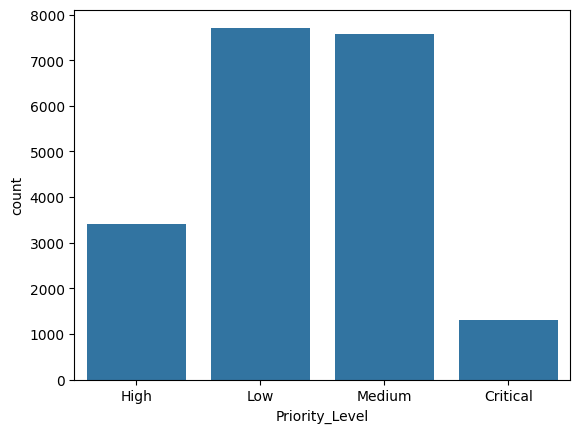

In [62]:
sns.countplot(data=df_5, x='Priority_Level')

Imbalanced classed 

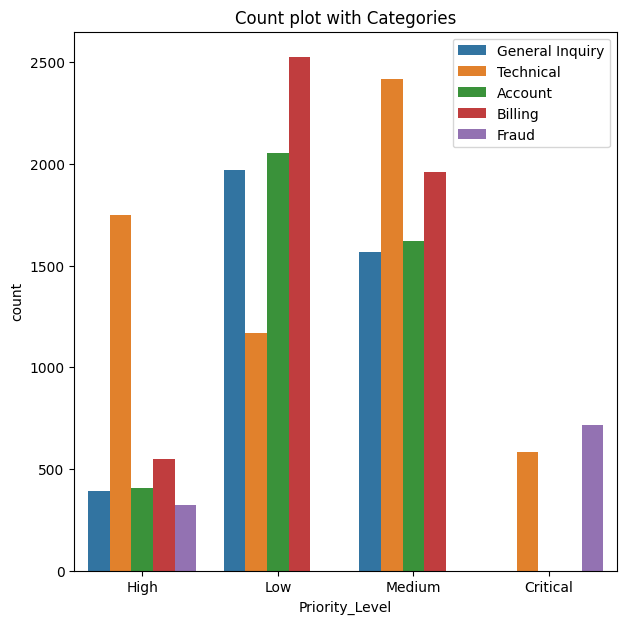

In [63]:
plt.figure(figsize=(7, 7)) 
sns.countplot(data=df_5, x='Priority_Level', hue='Issue_Category')
plt.legend(loc='upper right')
plt.title("Count plot with Categories")
plt.show()

# file 6

In [64]:
# Customer IT Support

In [65]:
df_6

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28582,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,high,en,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
28583,Datensperrung in der Kundschaftsbetreuung,"Es gab einen Datensperrungsunfall, bei dem ung...",Ich kann Ihnen bei dem Datensperrungsunfall he...,Incident,Product Support,high,de,400,Security,IT,Tech Support,Bug,NaN,NaN,NaN,NaN
28584,Problem mit der Videokonferenz-Software heute,Wichtigere Sitzungen wurden unterbrochen durch...,"Sehr geehrte/r [Name], leider wurde das Proble...",Incident,Human Resources,low,de,400,Bug,Performance,Network,IT,Tech Support,NaN,NaN,NaN
28585,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,high,en,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN


In [66]:
df_6=df_6[df_6['language']=='en']
df_6.shape

(16338, 16)

In [67]:
df_6.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')

In [68]:
df_6['priority'].unique()

array(['high', 'medium', 'low'], dtype=object)

In [69]:
df_6['tag_1'].unique()

array(['Account', 'Product', 'Billing', 'Feature', 'Outage', 'Network',
       'Bug', 'Inquiry', 'Marketing', 'Disruption', 'Hardware',
       'Documentation', 'Organization', 'Security', 'Feedback', 'Finance',
       'Compliance', 'Performance', 'Return', 'Maintenance', 'Sales',
       'Printer', 'Alert', 'IT', 'Synchronization', 'Display',
       'Customer Service', 'Smart Home', 'Customer', 'Refund', 'Login',
       'HR', 'Communication', 'Connectivity', 'Agile', 'Notification',
       'Outlook', 'Troubleshooting', 'Investment', 'Process Improvement',
       'Configuration', 'Support', 'Crash', 'Data Discrepancy',
       'Customer Support', 'Payment', 'Strategy', 'Accessibility',
       'Integration', 'Tech Support', 'Project',
       'Performance,Disruption,Outage,Monitoring,Analysis', 'Data',
       'Performance,Disruption,IT,Tech Support', 'Database', 'Health',
       'Analytics', 'Technical Support', 'Software', 'Server',
       'Salesforce', 'Security,IT,Tech Support', 'Project

In [70]:
df_6['queue'].unique()

array(['Technical Support', 'Returns and Exchanges',
       'Billing and Payments', 'Sales and Pre-Sales',
       'Service Outages and Maintenance', 'Product Support', 'IT Support',
       'Customer Service', 'Human Resources', 'General Inquiry'],
      dtype=object)

<Axes: xlabel='priority', ylabel='count'>

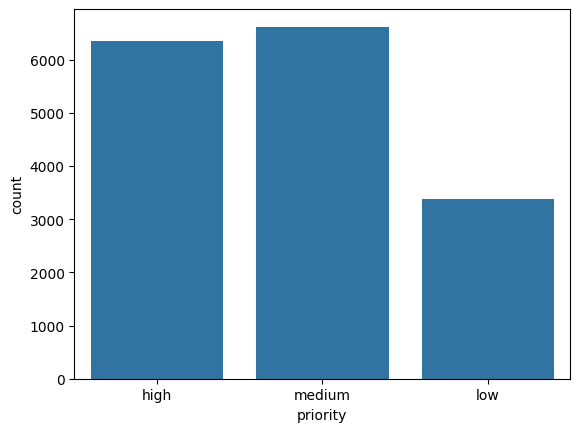

In [71]:
sns.countplot(data=df_6, x='priority')

imbalaced classed 

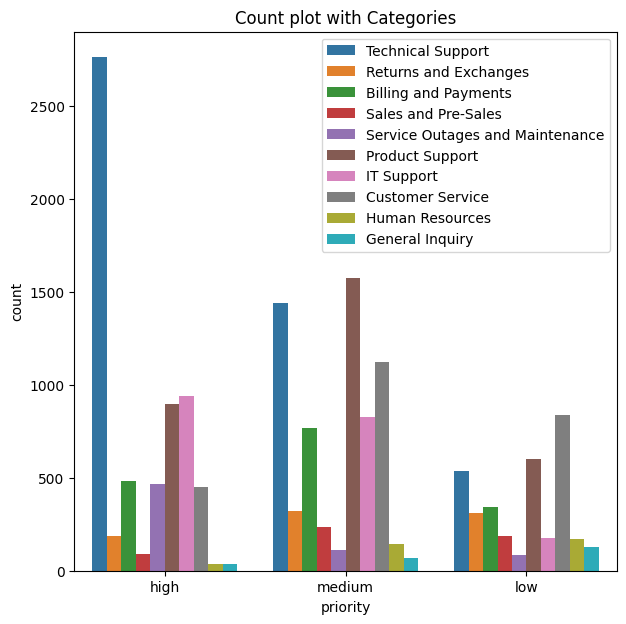

In [72]:
plt.figure(figsize=(7, 7)) 
sns.countplot(data=df_6, x='priority', hue='queue')
plt.legend(loc='upper right')
plt.title("Count plot with Categories")
plt.show()

# data Merge

In [73]:
df = pd.concat([df_1m, df_2m, df_3m, df_4m]).sample(frac=1, random_state=42).reset_index(drop=True)

In [74]:
df.head(5)

,text,priority,category
0,The application crashes whenever I try to uplo...,Urgent,Security
1,The system is not syncing data across devices ...,Urgent,Security
2,There seems to be a discrepancy in my billing ...,Medium,IT
3,I found a bug in the latest update affecting r...,Medium,Security
4,I'm having an issue with the {product_purchase...,Medium,Product


In [75]:
df['category'].value_counts()

category
Finance             11854
IT                  11835
Product              8308
Security             6683
Education            6000
Customer Service     5092
Name: count, dtype: int64

In [76]:
df.shape

(49772, 3)

<Axes: xlabel='priority', ylabel='count'>

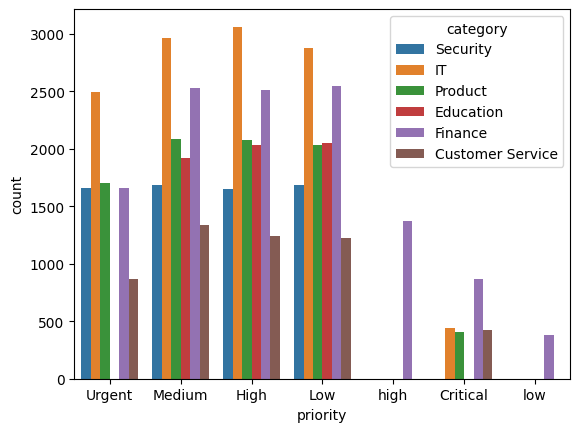

In [77]:
sns.countplot(data=df, x='priority', hue='category')

In [78]:
df['priority'].value_counts()

priority
High        12587
Medium      12510
Low         12414
Urgent       8382
Critical     2129
high         1374
low           376
Name: count, dtype: int64

In [79]:
df['priority']=df['priority'].map({'High':'high', 'Medium':'medium', 'Low': 'low', 'Critical':'Urgent', 'Urgent':'Urgent'})

<Axes: xlabel='priority', ylabel='count'>

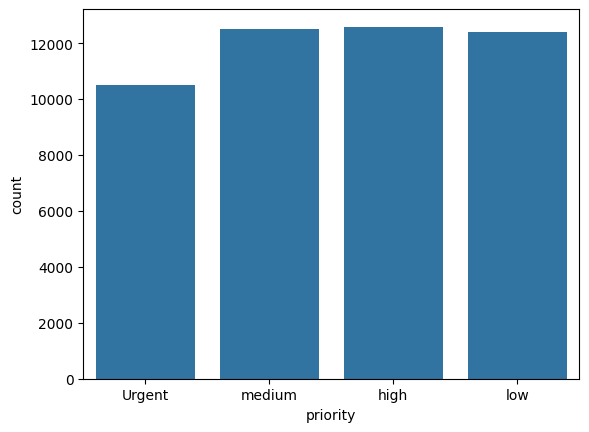

In [80]:
sns.countplot(data=df, x='priority')

<Axes: xlabel='priority', ylabel='count'>

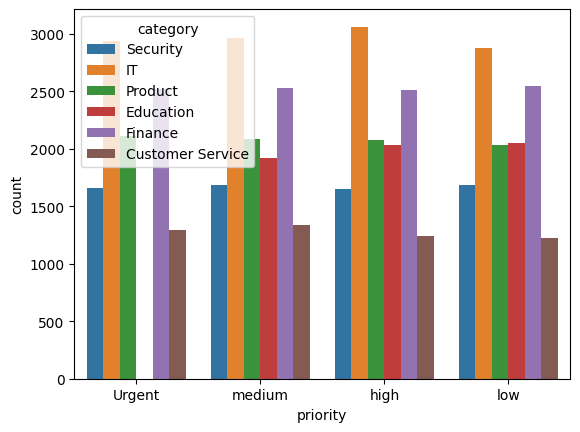

In [81]:
sns.countplot(data=df, x='priority', hue='category')

In [82]:
df.to_csv('data_final.csv')